In [1]:
import numpy as np
from mqt.qecc.circuit_synthesis import CNOTCircuit, gate_optimal_verification_stabilizers
from mqt.qecc.circuit_synthesis.faults import PureFaultSet

from spiderstate.cat_at_origin import cat_at_origin
from spiderstate.optimize_parity_matrix import optimize_fault_tolerant_matrix
from spiderstate.utils import load_qecc, flatten

%load_ext autoreload
%autoreload 2

In [6]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("23_1_7", "FAO")
t = d // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_x, t=t, max_col_ops=25, max_basis_tries=10_000, max_fault_size=1000)
print(row_M, sep="\n\n")
print(len(col_ops))

[[0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0]
 [1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1]
 [0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0]
 [0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0]
 [1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 0 0]
 [1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0]
 [1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0]
 [0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0]
 [1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]]
25


105


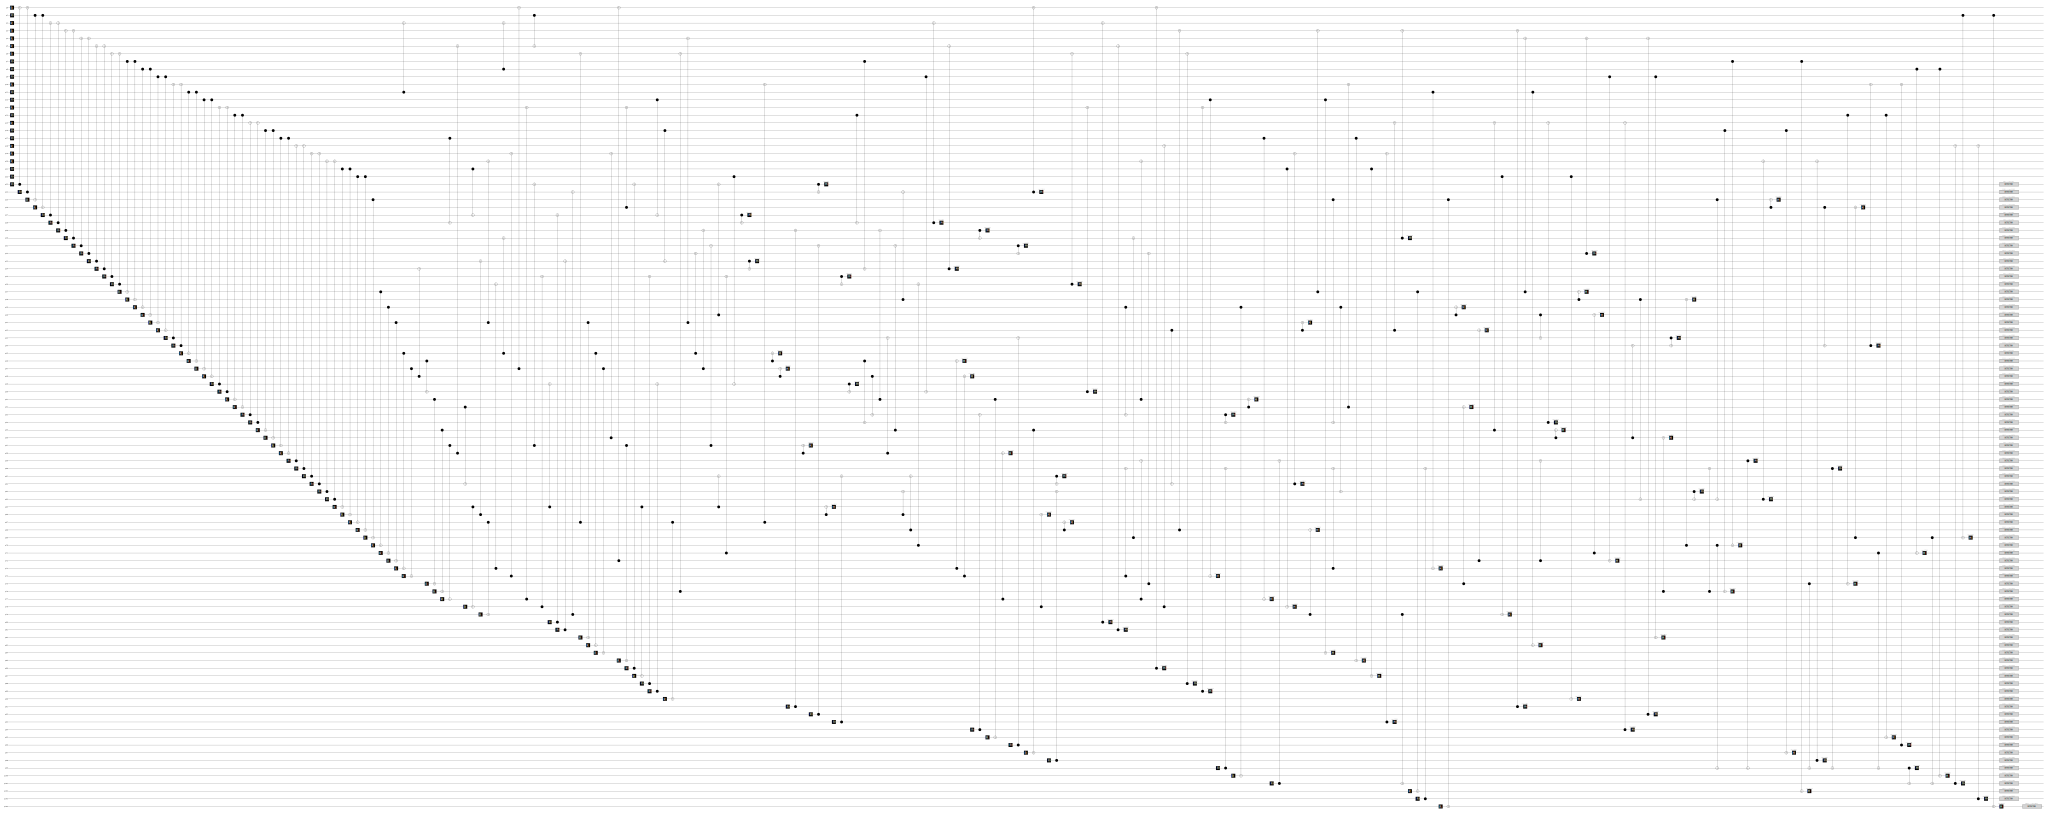

In [7]:
circ = cat_at_origin(row_M, d)
print(circ.num_qubits)
circ.diagram('timeline-svg')

[[0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0]
 [1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0]
 [0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

[(9, 19), (1, 18), (12, 10), (9, 15), (9, 0), (7, 0), (7, 5), (1, 13), (1, 3), (16, 6), (16, 4), (1, 2), (1, 0), (2, 0), (5, 20), (10, 19), (15, 13), (15, 4), (2, 15), (10, 3), (2, 10), (5, 6), (2, 5), (18, 2), (0, 18)]
31


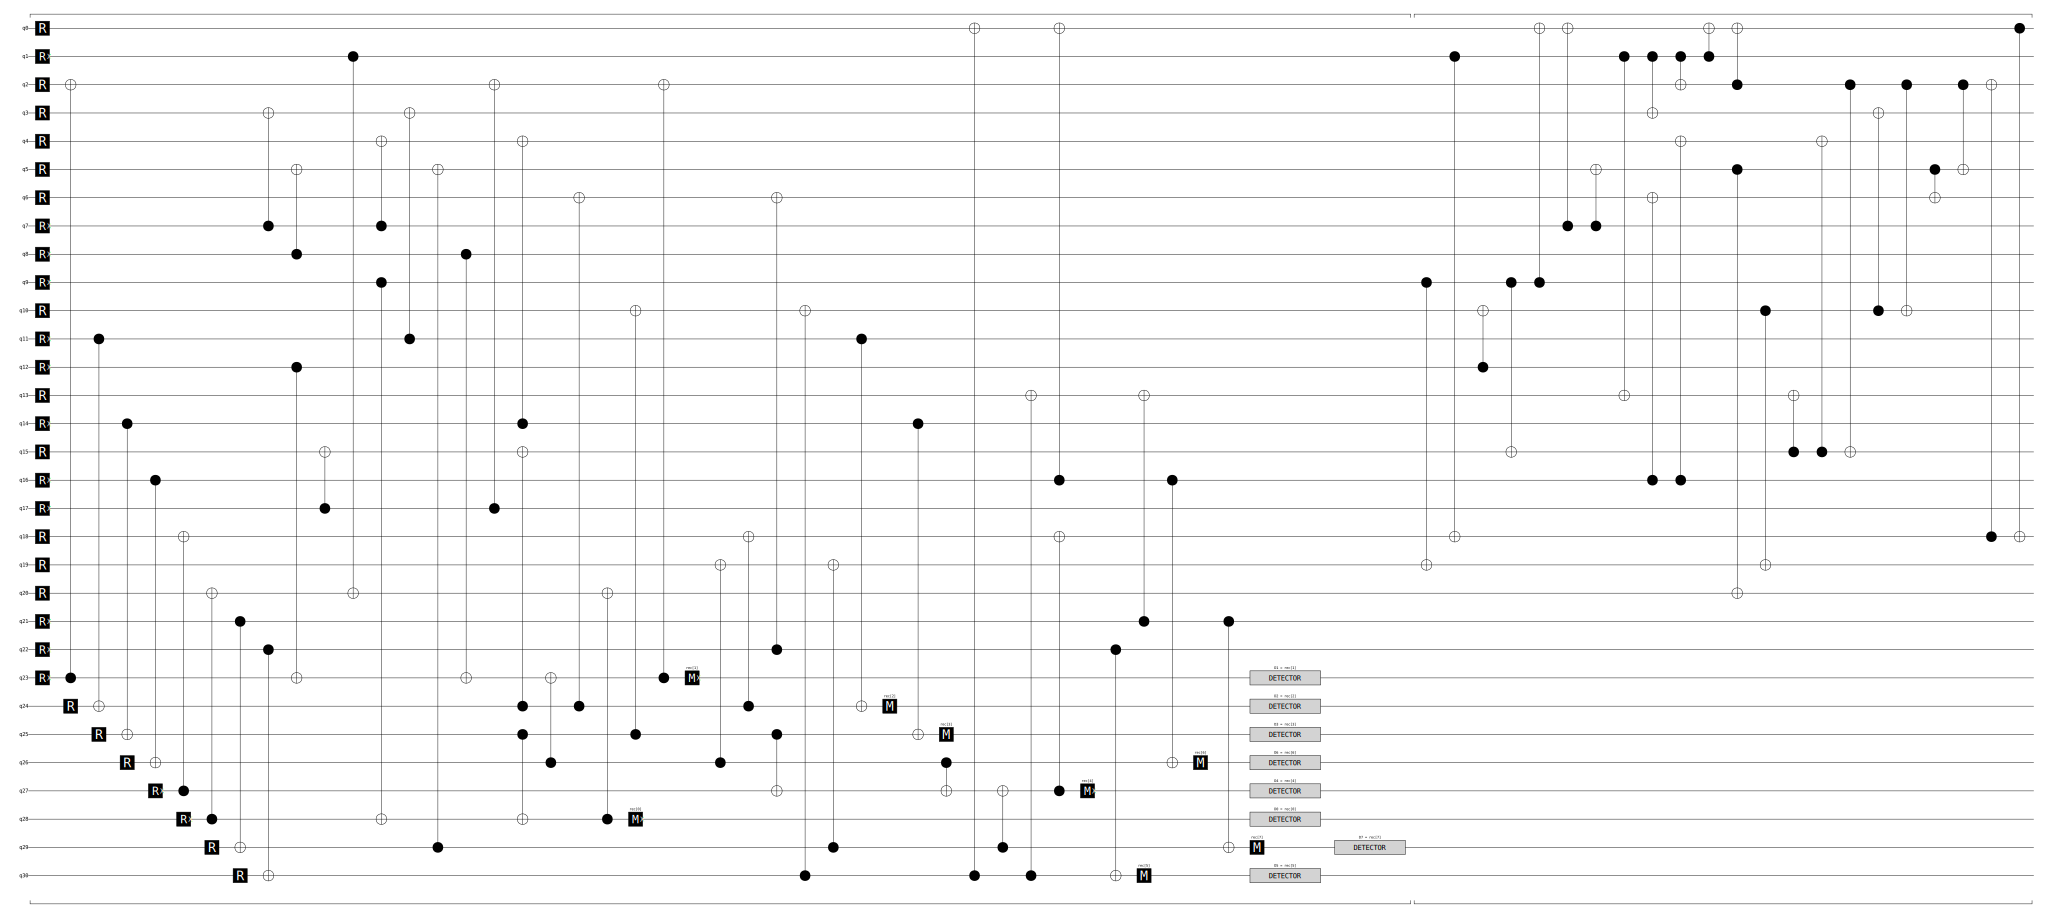

In [8]:
print(final_M, col_ops, sep="\n\n")

circ = cat_at_origin(final_M, d)
circ.append("TICK", [])
circ.append("CX", flatten(col_ops))
print(circ.num_qubits)
circ.diagram('timeline-svg')

In [5]:
circuit = circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_x.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [45]:
from mqt.qecc.circuit_synthesis import heuristic_verification_stabilizers


def compute_unitary_fault_set_1(cnots: list[tuple[int, int]], num_qubits: int, kind: str = "X"):
    """
    Computes a list of fault sets for a unitary CNOT circuit up to max_errors.
    Returns a list where index i contains the fault set for i+1 independent errors.
    """
    # 1. Establish the Physical Baseline
    circ = CNOTCircuit()
    seen = set()
    for (c, n) in cnots:
        if c not in seen:
            seen.add(c)
            circ.initialize_qubit(c, "X")
        if n not in seen:
            seen.add(n)
            circ.initialize_qubit(n, "Z")
    for rem in set(range(num_qubits)) - seen:
        circ.initialize_qubit(rem, "Z")
    circ.add_cnots(cnots)

    # 2. Compute the Root Fault Set (1 Error)
    single_faults = PureFaultSet.from_cnot_circuit(circ, kind=kind)
    single_faults.remove_zero_rows()
    single_faults.remove_duplicates()
    # single_faults.filter_by_weight_at_least(2, H_x)

    return single_faults


def compute_unitary_bad_fault_set_1(cnots: list[tuple[int, int]], H, kind: str = "X"):
    single_faults = compute_unitary_fault_set_1(cnots, H.shape[1], kind=kind)
    single_faults.filter_by_weight_at_least(2, H)
    return single_faults



fsx_1 = compute_unitary_bad_fault_set_1(col_ops, H=H_x, kind="X")
print(fsx_1)
fsz_1 = compute_unitary_bad_fault_set_1(col_ops, H=np.concatenate((H_z, L_z)), kind="Z")
print(fsz_1)

print()

[ver_x_stabs_layers] = heuristic_verification_stabilizers([fsx_1], np.concatenate((H_z, L_z)))
print(ver_x_stabs_layers)
[ver_z_stabs_layers] = heuristic_verification_stabilizers([fsz_1], np.concatenate((H_x, L_x)))
print(ver_z_stabs_layers)

PureFaultSet(num_qubits=17, faults=[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])
PureFaultSet(num_qubits=17, faults=[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

[array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1], dtype=int8), array([0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1], dtype=int8)]
[array([0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1]), array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1])]


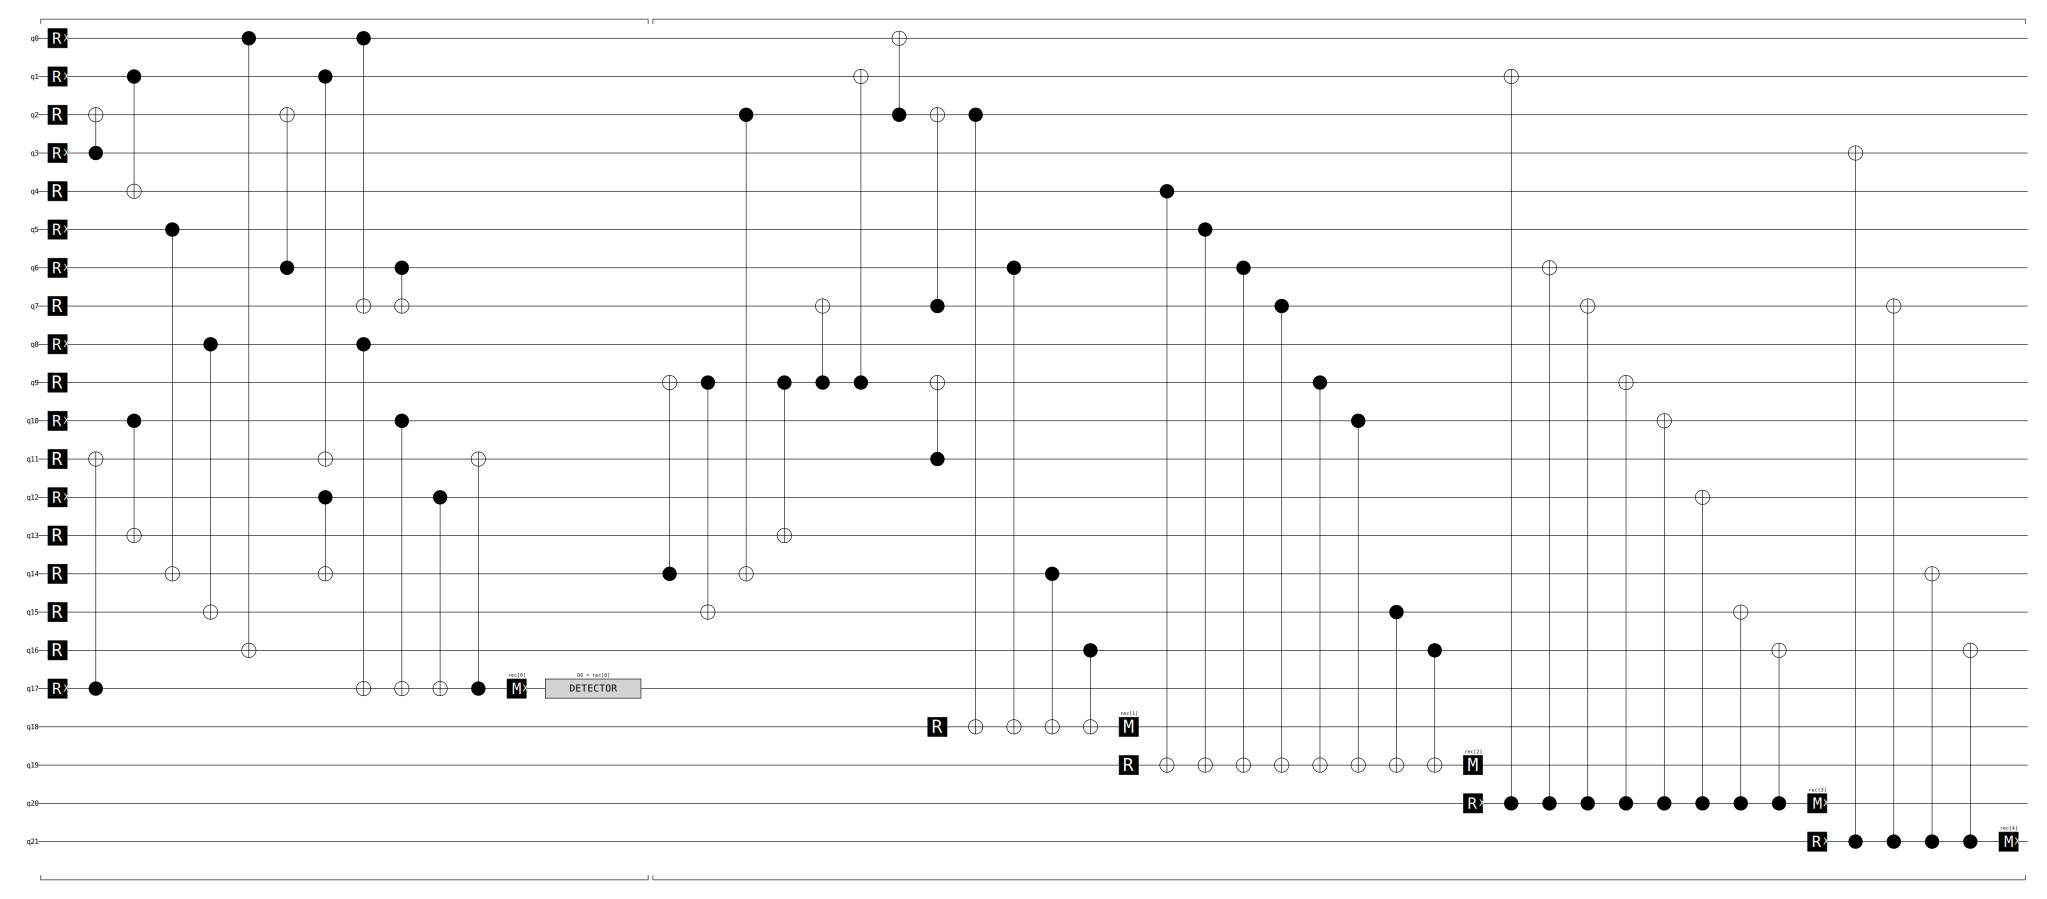

In [46]:
for layer in ver_x_stabs_layers:
    N = circ.num_qubits
    circ.append("R", [N])
    for i in np.where(layer)[0]:
        circ.append("CNOT", [i, N])
    circ.append("M", [N])
for layer in ver_z_stabs_layers:
    N = circ.num_qubits
    circ.append("RX", [N])
    for i in np.where(layer)[0]:
        circ.append("CNOT", [N, i])
    circ.append("MX", [N])
circ.diagram('timeline-svg')

In [10]:
from mqt.qecc.circuit_synthesis.faults import product_fault_set


def compute_next_unitary_fault_set(single_faults: PureFaultSet, last_faults: PureFaultSet, ver_x_stabs_layers, weight):
    """
    Computes a list of fault sets for a unitary CNOT circuit up to max_errors.
    Returns a list where index i contains the fault set for i+1 independent errors.
    """
    next_faults = product_fault_set(last_faults, single_faults)
    double_last = product_fault_set(last_faults, last_faults)

    next_faults.faults = np.concatenate((double_last.faults, next_faults.faults))
    try:
        undetectable_indices = next_faults.get_undetectable_faults_idx(ver_x_stabs_layers)
        next_faults.faults = np.delete(next_faults.faults, undetectable_indices, axis=0)
    except ValueError:
        pass

    next_faults.faults = np.concatenate((last_faults.faults, next_faults.faults))

    next_faults.remove_zero_rows()
    next_faults.remove_duplicates()
    next_faults.filter_by_weight_at_least(weight, H_x)

    return next_faults

next_fs = compute_next_unitary_fault_set(
    compute_unitary_fault_set_1(col_ops, num_qubits=H_x.shape[1], kind="X"),
    fsx_1,
    ver_x_stabs_layers,
    3
)

print(next_fs)
[next_ver_x_stabs_layers] = gate_optimal_verification_stabilizers([next_fs], np.concatenate((H_z, L_z)), max_timeout=5)
print(next_ver_x_stabs_layers)

PureFaultSet(num_qubits=17, faults=[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1], [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 

In [26]:
np.sum(L_x,axis=0) % 2

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0])

In [21]:
print(np.sum(next_fs, axis=1))

[3 3 3 3 3 4 3 3 3 3 3 3 3 3 3 3 3 3 4 3 3 3 3 3 4 3 3 3 3 4 3 3 3 3 3 3 3
 4 4 4 4 3 3 4 3 4 4 3 3 3 3 3 3 3 4 3 4 3 4 3 3 3 4 4 3 3 3 3 3 3 4 4]
